In [2]:
import numpy as np
import pandas as pd

from plotly.subplots import make_subplots

from pychemelt import Monomer
from pychemelt.utils.plotting import *

import plotly.graph_objs as go

import sys
sys.path.append('../')
from scripts import display_figure_static, set_condition_indexes_to_false

In [ ]:
INDEX = 13
NAME = "G5A" # Name used in the manuscript

# creating a Sample object for the storage and processing of the DSF data
sample = Monomer()

# reading the data
sample.read_file(f'../../data/retiter1_GB1_GH1.xlsx')

sample.set_denaturant_concentrations()

# Selecting conditions
sample.set_signal(['330 nm'])#, '350 nm'])

conditions = [True]*48
# Index of the curves to be excluded from the analysis, starting from 1
outliers_or_other_data = ["23-48","8","9","19","20"] 

five_point_one = np.where(sample.denaturant_concentrations_pre == 5.1)[0]
print(f"Index of the curve with 5.1 M denaturant: {five_point_one}")

conditions = set_condition_indexes_to_false(conditions,outliers_or_other_data)

#using all curves except the curve without denaturant as in the paper
sample.select_conditions(conditions,normalise_to_global_max=True)
sample.set_temperature_range(40, 95)

plot_config = PlotConfig()
plot_config.font_size = 24

legend_config = LegendConfig()
legend_config.color_bar_orientation = "h"
legend_config.color_bar_length = 0.6
legend_config.color_bar_x_pos = 0.7
legend_config.color_bar_y_pos = 0.9

#Plotting the selected signals against the temperature
fig = plot_unfolding(sample,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

Index of the curve with 5.1 M denaturant: [ 7 18 29 40]


In [ ]:
# Reducing the amount of data and preprocessing steps for a faster analysis
sample.pre_fit = False
sample.max_points = 200

sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
    native_baseline_type='linear',
    unfolded_baseline_type='exponential',
)

# estimations of parameters
sample.estimate_derivative()
sample.guess_Tm()

# All local fit for parameter estimation
sample.fit_thermal_unfolding_local()

# Setting the number of residues of the protein for an initial estiamte of the Cp value
# We use a lower value than expected because of the hyperstability.
sample.n_residues = 60 
sample.guess_Cp()

sample.set_signal_id()

sample.compare_models(
    native_baseline_types=['linear','quadratic','exponential'],
    unfolded_baseline_types=['linear','quadratic','exponential'],
    global_model_types=['global_global','global_global_global'],
    neff=None
)


/Users/oburastero/myenv/lib/python3.12/site-packages/pychemelt/utils/math.py:204: RuntimeWarning: overflow encountered in multiply
  return a + c * np.exp(-alpha * dt) + den_slope * d
/Users/oburastero/myenv/lib/python3.12/site-packages/pychemelt/utils/math.py:204: RuntimeWarning: overflow encountered in exp
  return a + c * np.exp(-alpha * dt) + den_slope * d


In [10]:
print(sample.comparison_df)
# add sample name to the comparison dataframe - first column
sample.comparison_df.insert(0, 'Sample', NAME)
# Export to csv - use sample name as filename
sample.comparison_df.to_csv(f'./comparison_tables/{INDEX}_{NAME}_comparison.csv', index=False)

#sample.params_df[:4]

  Native Baseline Unfolded Baseline                           Model Type  \
0       quadratic       exponential  Global slopes and global intercepts   
1          linear            linear  Global slopes and global intercepts   
2          linear       exponential  Global slopes and global intercepts   
3       quadratic            linear  Global slopes and global intercepts   
4     exponential       exponential  Global slopes and global intercepts   
5       quadratic         quadratic  Global slopes and global intercepts   
6     exponential            linear  Global slopes and global intercepts   
7     exponential         quadratic  Global slopes and global intercepts   
8          linear         quadratic  Global slopes and global intercepts   

      Tm    ΔHm   ΔCp  m-value      AIC      BIC     EBIC  Reduced χ²  
0  100.9   91.4  6.99     1.07  2514.37  2692.87  3017.27      2.8903  
1   95.9  152.2  3.56     1.22  2830.14  2997.12  3304.22      3.3107  
2  123.8  175.5  5.00  

In [1]:
# Replace sample with the best model
best_model = sample.fit_objects[5]

NameError: name 'sample' is not defined

In [16]:
# Estimate error using leave_one_out cross validation
# We do not do it here because the fittings are not good
do_loo = False
if do_loo:
    best_model.leave_one_out_cross_validation()

    # Save the leave one out results to a csv file
    best_model.loo_df.to_csv(f'./leave_one_out_results/{INDEX}_{NAME}_loo.csv', index=False)

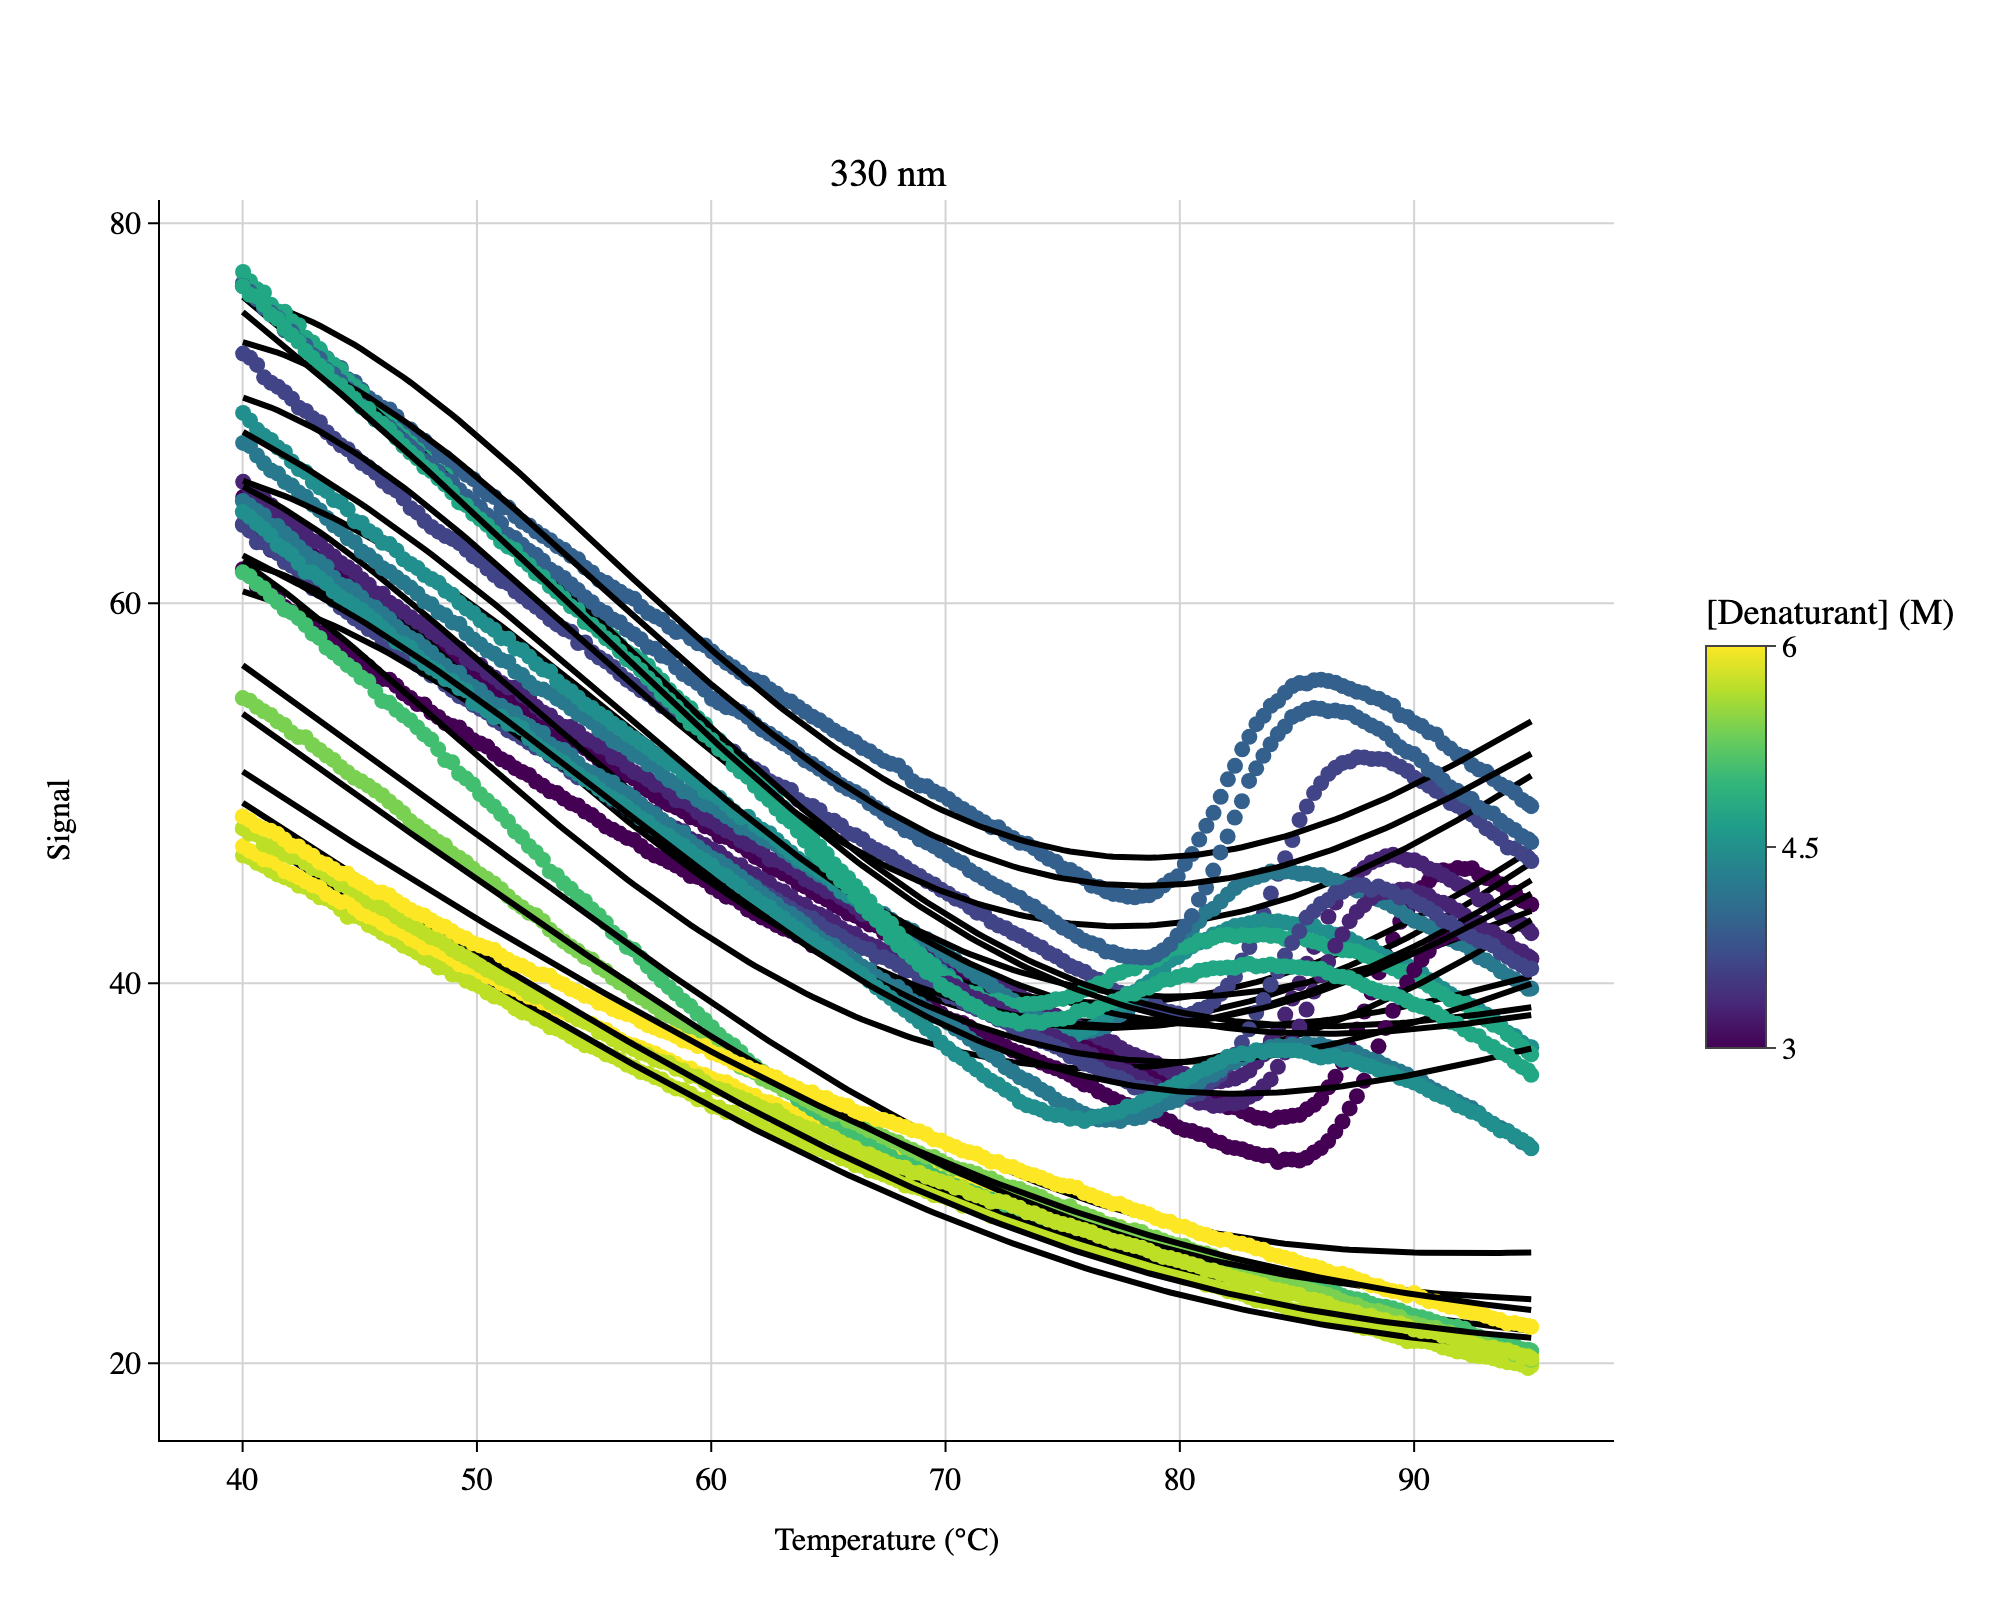

In [26]:
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

here


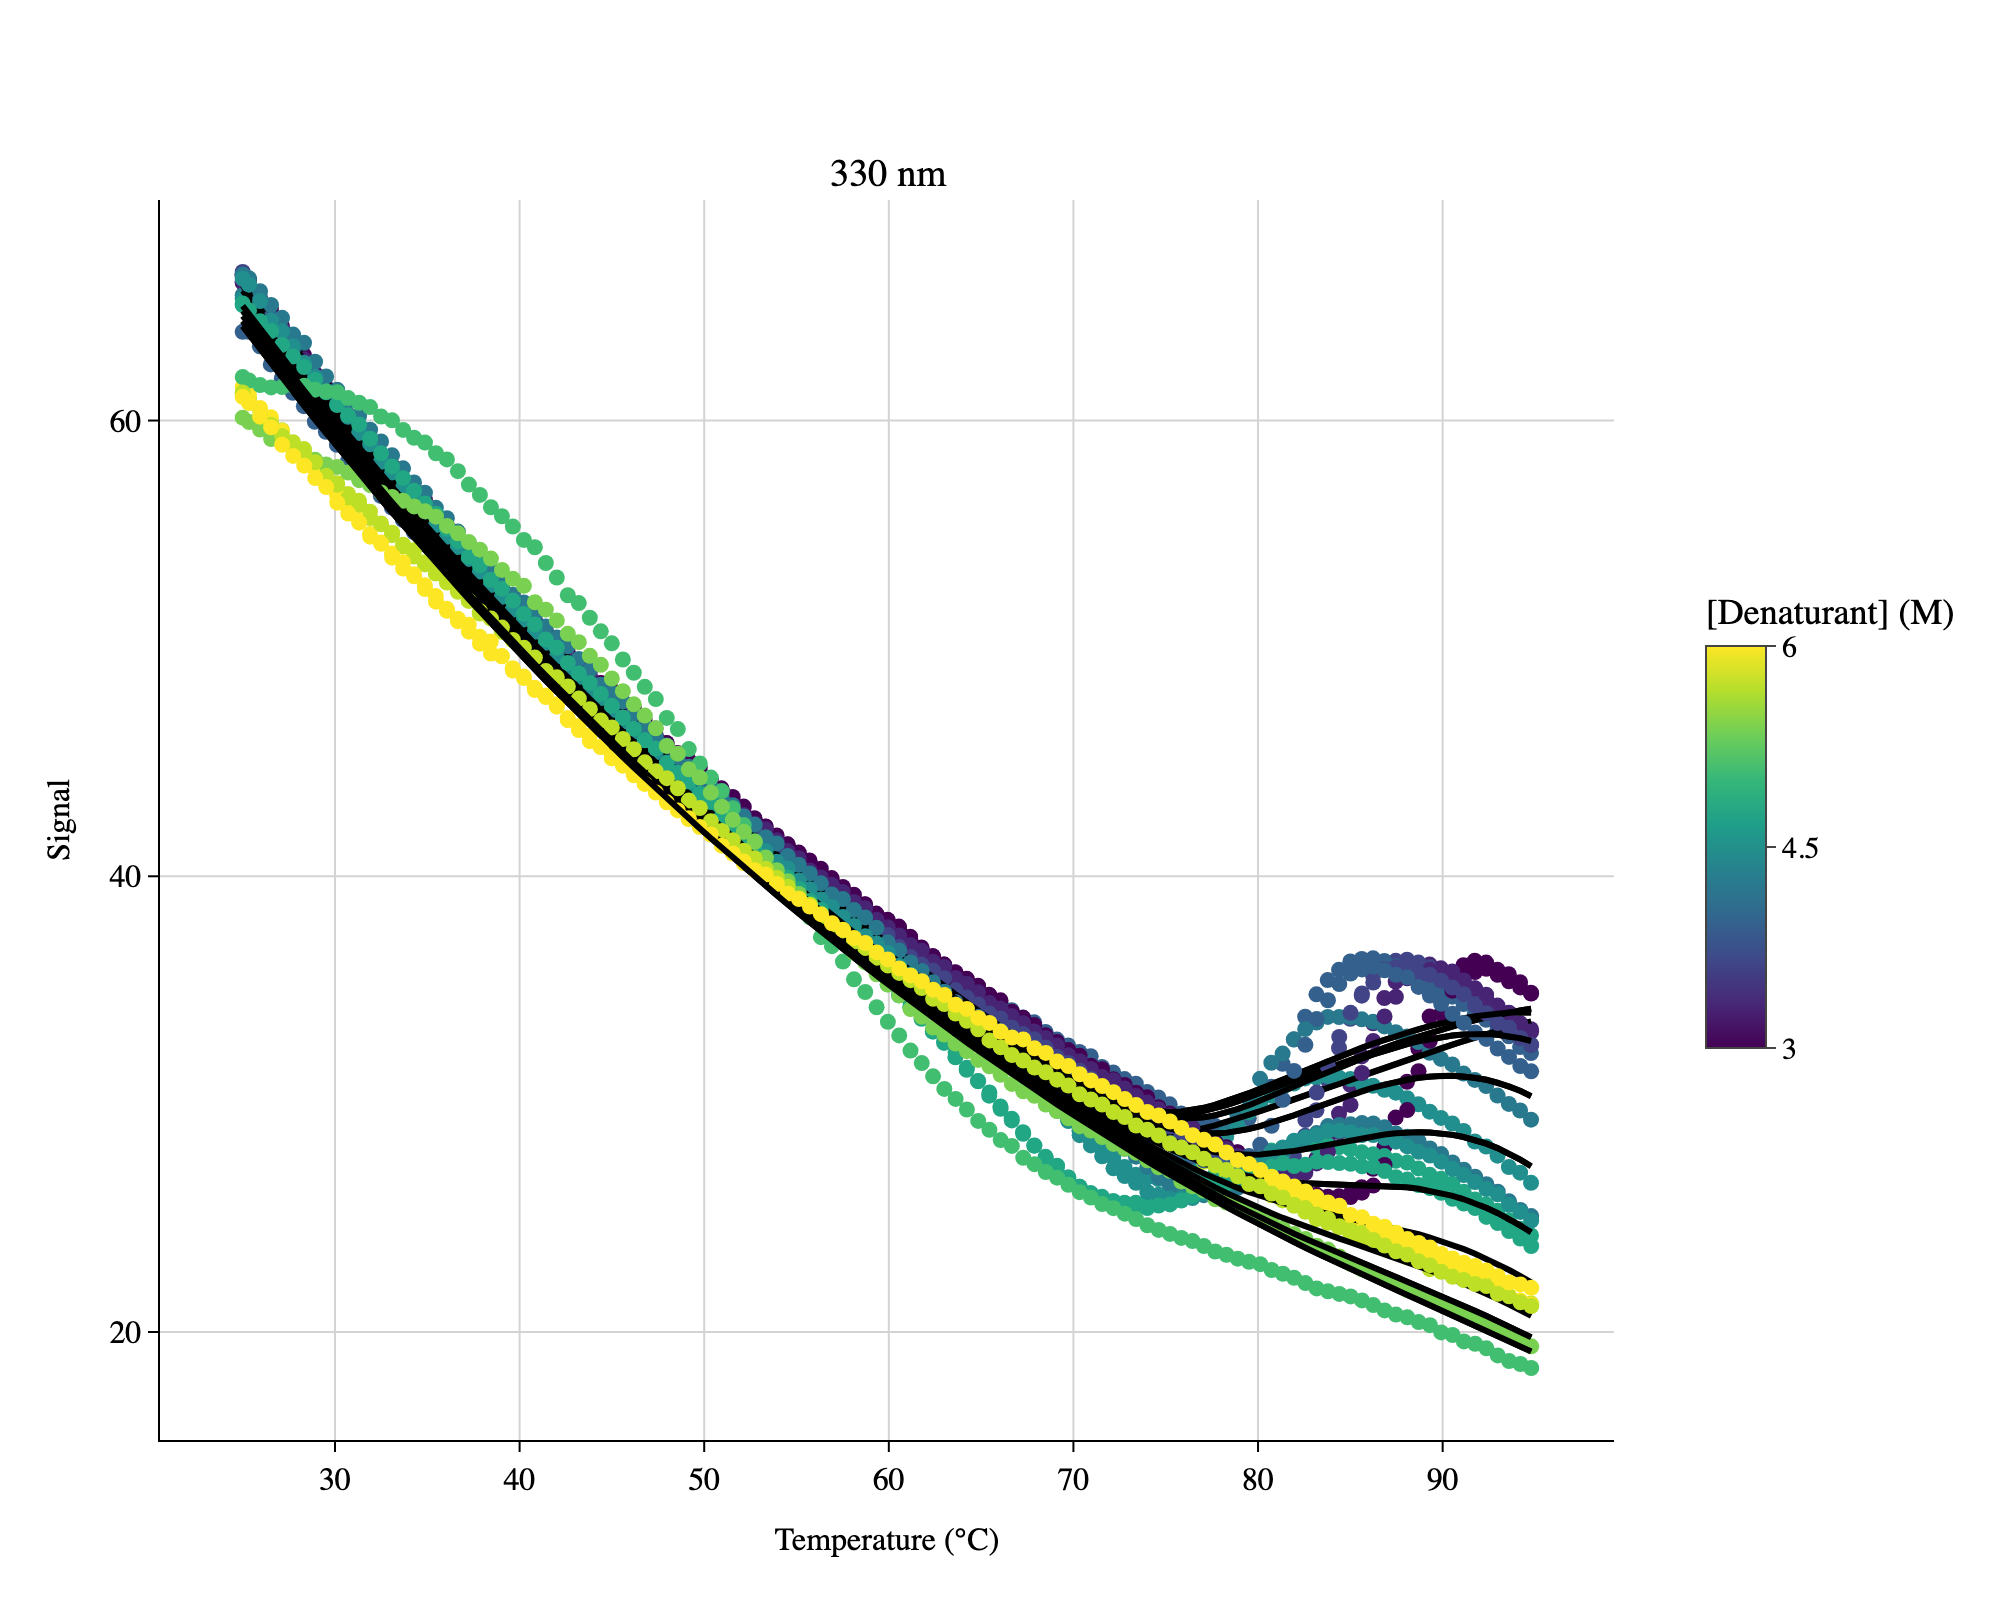

In [ ]:
# Plot the curves taking into account the effect of the scaling factor
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config,use_scaled_data=True)
# save figure
#fig.write_image(f"./figures/{INDEX}_{NAME}_unfolding_curves_fitted_scaled.png")

display_figure_static(fig,height=800, width=1000)